# GPRPy Library: Processing Example

This notebook demonstrates how to use the `gprpy_lib` to load, process, and visualize Ground Penetrating Radar (GPR) data.

In [1]:
import gprpy_lib as gpr
import numpy as np

/home/allan/Documentos/Github/GPRPy/.venv/lib/python3.14/site-packages/gprpy_lib/gprpyTools.py:324: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  if topomat.shape[1] is 3:
/home/allan/Documentos/Github/GPRPy/.venv/lib/python3.14/site-packages/gprpy_lib/gprpyTools.py:338: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  elif topomat.shape[1] is 2:
/home/allan/Documentos/Github/GPRPy/.venv/lib/python3.14/site-packages/gprpy_lib/gprpyTools.py:440: SyntaxWarning: "is" with 'int' literal. Did you mean "=="?
  if gpsmat.shape[1] is 3:


## 1. Loading Data

In [72]:
filepath = '../gprpy/exampledata/GSSI/FILE____032.DZT'
data, info = gpr.gprIO_DZT.readdzt(filepath)

## 2. Initial Data Visualization

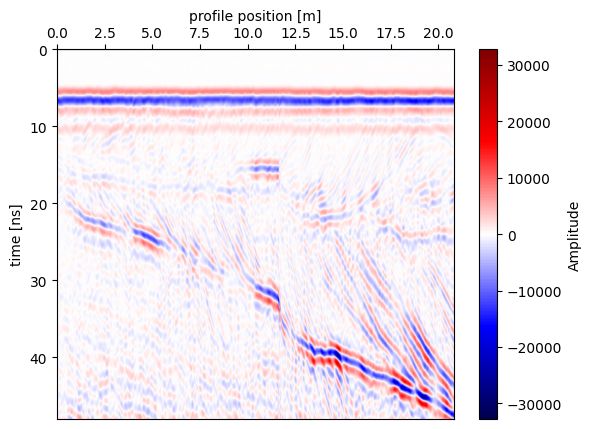

In [73]:
profilePos = info['rhf_position'] + np.linspace(0.0, data.shape[1] / info['rhf_spm'], data.shape[1])
twtt = np.linspace(0, info['rhf_range'], info['rh_nsamp'])
gpr.plot_profile(data, profilePos, twtt, color="seismic")

## 3. Data Processing

In [74]:
#Correct
new_zero_time = 8.0
zero_index = np.abs(twtt - new_zero_time).argmin()

data_corrected = data[zero_index:, :]
twtt = twtt[zero_index:] - new_zero_time

# Remove mean trace
data_processed = gpr.remMeanTrace(data_corrected, ntraces=200)

# Example: Apply a gain factor
final_data= gpr.tpowGain(data_processed,twtt, power=.25) 


done with removing mean trace


## 4. Processed Data Visualization

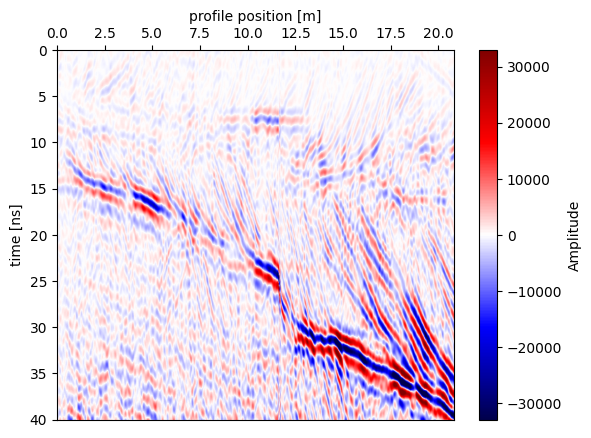

In [75]:
gpr.plot_profile(final_data, profilePos, twtt,color="seismic",contrast=2.0)